# Heterogeneous relational Koopman on multiplex graphs

This notebook trains a **RelGraph** encode/decode stack with
`koopman="hetero_graph"` on a small seeded multiplex sequence whose latent
dynamics are planted with two distinct relation banks. An ablation table
compares relational, relation-ignoring (union adjacency), and dense-joint
`koopman="graph"` models on hold-out multi-step MSE and trainable parameter
counts. Relational recovery is **not** guaranteed; the table reports whichever
arm wins on this fixture.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import (
    GraphSnapshotSequence,
    HeteroGraphSnapshotSequence,
)
from koopman_graph.nn import RelGraphDecoder, RelGraphEncoder
from koopman_graph.operators import HeteroGraphKoopmanOperator

SEED = 0
NUM_NODES = 6
IN_CHANNELS = 2
LATENT_DIM = 4
HIDDEN = 8
NUM_TIMESTEPS = 24
TRAIN_T = 16
HOLD_STEPS = 3
EPOCHS = 35
LR = 1e-2

torch.manual_seed(SEED)
print(f"koopman_graph {koopman_graph.__version__}; torch {torch.__version__}")


koopman_graph 0.10.0; torch 2.13.0


## Motivation and background

Homogeneous graph Koopman models use one adjacency and a single neighbor
factor. Multiplex systems expose several relation types (for example distinct
contact layers or branch roles). A relational operator of the form

$$
\mathrm{vec}(Z_{t+1})
=
\bigl(
I_N \otimes K_{\mathrm{self}}
+ \sum_{r=1}^{R} \hat{A}_r \otimes K_r
\bigr)
\mathrm{vec}(Z_t)
$$

keeps a separate \(d \times d\) block per relation (R-GCN-style message
banks; Schlichtkrull et al., 2018 — normalization / per-relation motivation
only). Here \(\mathrm{vec}(Z)\) is the package C-order flatten
(\(Z.\mathrm{reshape}(-1)\): node blocks of width \(d\)), and \(\hat{A}_r\) is
the per-relation degree-normalized adjacency. Collapsing relations into one
union edge set is the natural type-/relation-ignoring control; a homogeneous
`koopman="graph"` model is the dense-joint baseline on the same physical
features.

Optional typed peers such as HGT (Hu et al., 2020) exist under
`koopman_graph.nn` but are **not** required for hetero support and are not used
below. Factory `koopman="hetero_graph"` pairs with RelGraph only.


## Minimal example: plant multi-relation dynamics, fit RelGraph

Build a two-relation multiplex sequence by advancing features with a known
`HeteroGraphKoopmanOperator`, then fit a RelGraph / `hetero_graph` model
end-to-end on the training prefix.


In [2]:
R0 = torch.tensor([[0, 1, 2, 3, 4], [1, 2, 3, 4, 5]], dtype=torch.long)
R1 = torch.tensor([[5, 4, 3, 2, 1], [4, 3, 2, 1, 0]], dtype=torch.long)
EDGE_BANKS = [R0, R1]
UNION = torch.cat(EDGE_BANKS, dim=1)

K_SELF = torch.tensor([[0.75, 0.05], [0.00, 0.65]])
K_RELATIONS = [
    torch.tensor([[0.20, 0.00], [0.00, 0.15]]),
    torch.tensor([[0.00, -0.12], [0.10, 0.00]]),
]


def plant_multiplex_sequence(
    num_timesteps: int = NUM_TIMESTEPS,
    *,
    seed: int = SEED,
) -> HeteroGraphSnapshotSequence:
    # Roll planted relational dynamics into multiplex HeteroData.
    generator = torch.Generator().manual_seed(seed)
    operator = HeteroGraphKoopmanOperator(
        IN_CHANNELS,
        num_relations=2,
        init_mode="identity",
    )
    operator.set_dense_matrices(K_SELF, K_RELATIONS)
    state = torch.randn(NUM_NODES, IN_CHANNELS, generator=generator)
    snapshots: list[HeteroData] = []
    with torch.no_grad():
        for _ in range(num_timesteps):
            data = HeteroData()
            data['node'].x = state.clone()
            data['node', 'r0', 'node'].edge_index = R0
            data['node', 'r1', 'node'].edge_index = R1
            snapshots.append(data)
            state = operator(state, EDGE_BANKS)
    return HeteroGraphSnapshotSequence(snapshots)


full_seq = plant_multiplex_sequence()
train_seq = full_seq.slice(0, TRAIN_T)
hold_seq = full_seq.slice(TRAIN_T, NUM_TIMESTEPS)
print(
    f"multiplex train T={train_seq.num_timesteps}, "
    f"hold T={hold_seq.num_timesteps}, |R|={len(train_seq.edge_types)}"
)


multiplex train T=16, hold T=8, |R|=2


Fit the relational RelGraph / `hetero_graph` stack on the training prefix.


In [3]:
relational = GraphKoopmanModel(
    encoder=RelGraphEncoder(
        IN_CHANNELS,
        HIDDEN,
        LATENT_DIM,
        num_relations=2,
        num_layers=1,
    ),
    decoder=RelGraphDecoder(
        LATENT_DIM,
        HIDDEN,
        IN_CHANNELS,
        num_relations=2,
        num_layers=1,
    ),
    latent_dim=LATENT_DIM,
    time_step=1.0,
    koopman="hetero_graph",
)
history = relational.fit(train_seq, epochs=EPOCHS, lr=LR)
print(f"relational final train loss = {history.loss[-1]:.4e}")


relational final train loss = 5.0663e-03


## Progressive deep dive: relation-ignoring and dense-joint controls

1. **Relation-ignoring** — same RelGraph / hetero factory with `|R|=1`, edges
   replaced by the union of both banks.
2. **Dense joint** — homogeneous GNN peers with `koopman="graph"` on the same
   features and union adjacency.


In [4]:
def as_single_relation(
    sequence: HeteroGraphSnapshotSequence,
) -> HeteroGraphSnapshotSequence:
    # Collapse multiplex edges into one union relation bank.
    snapshots = []
    for snapshot in sequence:
        data = HeteroData()
        data['node'].x = snapshot['node'].x
        data['node', 'r_all', 'node'].edge_index = UNION
        snapshots.append(data)
    return HeteroGraphSnapshotSequence(snapshots)


def as_homogeneous(
    sequence: HeteroGraphSnapshotSequence,
) -> GraphSnapshotSequence:
    # Homogeneous Data view on the union adjacency.
    snapshots = [
        Data(x=snapshot['node'].x, edge_index=UNION)
        for snapshot in sequence
    ]
    return GraphSnapshotSequence(snapshots)


train_union = as_single_relation(train_seq)
hold_union = as_single_relation(hold_seq)
train_homo = as_homogeneous(train_seq)
hold_homo = as_homogeneous(hold_seq)
print(
    f"union |R|={len(train_union.edge_types)}, "
    f"homogeneous N={train_homo.num_nodes}"
)


union |R|=1, homogeneous N=6


Fit the `|R|=1` union control and the homogeneous `koopman="graph"` baseline.


In [5]:
relation_ignoring = GraphKoopmanModel(
    encoder=RelGraphEncoder(
        IN_CHANNELS,
        HIDDEN,
        LATENT_DIM,
        num_relations=1,
        num_layers=1,
    ),
    decoder=RelGraphDecoder(
        LATENT_DIM,
        HIDDEN,
        IN_CHANNELS,
        num_relations=1,
        num_layers=1,
    ),
    latent_dim=LATENT_DIM,
    time_step=1.0,
    koopman="hetero_graph",
)
relation_ignoring.fit(train_union, epochs=EPOCHS, lr=LR)

dense_joint = GraphKoopmanModel(
    encoder=GNNEncoder(
        IN_CHANNELS,
        HIDDEN,
        LATENT_DIM,
        num_layers=1,
    ),
    decoder=GNNDecoder(
        LATENT_DIM,
        HIDDEN,
        IN_CHANNELS,
        num_layers=1,
    ),
    latent_dim=LATENT_DIM,
    time_step=1.0,
    koopman="graph",
)
dense_joint.fit(train_homo, epochs=EPOCHS, lr=LR)
print("controls fitted")


controls fitted


### Optional: typed IEEE 118 topology helper

`IEEE118DynamicBenchmark.generate_typed` partitions MATPOWER buses into
generator / load / slack stores. Dynamics remain **simulated** (Laplacian
diffusion + load ramp), not real grid telemetry. This cell only checks that a
typed sequence constructs; it is **not** part of the ablation table and does
not fit a typed RelGraph model.


In [6]:
from koopman_graph.datasets import IEEE118DynamicBenchmark
from koopman_graph.datasets.ieee118 import SIMULATED_DYNAMICS_DISCLAIMER

typed_topo = IEEE118DynamicBenchmark.load_typed_topology()
typed_seq = IEEE118DynamicBenchmark.generate_typed(
    num_timesteps=4, seed=0
)
print(SIMULATED_DYNAMICS_DISCLAIMER)
print("typed node types:", typed_topo.node_type_names)
print("typed counts:", typed_topo.num_nodes_dict)
print(
    f"typed sequence T={typed_seq.num_timesteps}, "
    f"N_total={typed_seq.num_nodes_total}, |R|={len(typed_seq.edge_types)}"
)


IEEE 118 typed / homogeneous dynamics in this package are simulated (Laplacian diffusion + load ramp) on the MATPOWER case118 topology; they are not real grid telemetry.
typed node types: ('generator', 'load', 'slack')
typed counts: {'generator': 53, 'load': 64, 'slack': 1}
typed sequence T=4, N_total=118, |R|=8


## Results

Hold-out metric: mean multi-step MSE over the first `HOLD_STEPS` forecasts from
the hold-out origin (node features). Parameter counts are trainable tensors
only. Inspect which bar is lowest — relational is favored by the planted
generator on this seed, but a relational loss would be reported the same way.


In [7]:
def count_params(model: GraphKoopmanModel) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


def holdout_mse(
    model: GraphKoopmanModel,
    sequence: HeteroGraphSnapshotSequence | GraphSnapshotSequence,
    *,
    steps: int = HOLD_STEPS,
) -> float:
    predictions = model.predict(sequence[0], steps=steps)
    total = 0.0
    for horizon, prediction in enumerate(predictions):
        truth = sequence[horizon + 1]
        if isinstance(prediction, HeteroData):
            total += float(
                torch.mean(
                    (prediction['node'].x - truth['node'].x) ** 2
                )
            )
        else:
            total += float(torch.mean((prediction.x - truth.x) ** 2))
    return total / steps


rows = [
    ("relational (|R|=2)", relational, hold_seq),
    ("relation-ignoring (|R|=1 union)", relation_ignoring, hold_union),
    ("dense joint (koopman=graph)", dense_joint, hold_homo),
]

table = []
for name, model, sequence in rows:
    table.append(
        {
            "model": name,
            "params": count_params(model),
            "holdout_mse": holdout_mse(model, sequence),
        }
    )

header = f"{'model':<34} {'params':>8} {'holdout_mse':>12}"
print(header)
for row in table:
    print(
        f"{row['model']:<34} {row['params']:>8d} "
        f"{row['holdout_mse']:>12.4e}"
    )

winner = min(table, key=lambda row: row["holdout_mse"])
print()
print(f"lowest hold-out MSE: {winner['model']}")
if winner["model"] != "relational (|R|=2)":
    print(
        "Relational did not win on this seeded fixture; "
        "report the table as-is rather than selecting a flattering seed."
    )


model                                params  holdout_mse
relational (|R|=2)                      102   4.5756e-03
relation-ignoring (|R|=1 union)          70   6.0067e-03
dense joint (koopman=graph)              54   1.2793e-02

lowest hold-out MSE: relational (|R|=2)


Bar chart of the same hold-out MSE (left; lower is better) and trainable
parameter counts (right). On seed 0 the relational arm is lowest-error and
largest; if another arm wins, keep that outcome in the figure.


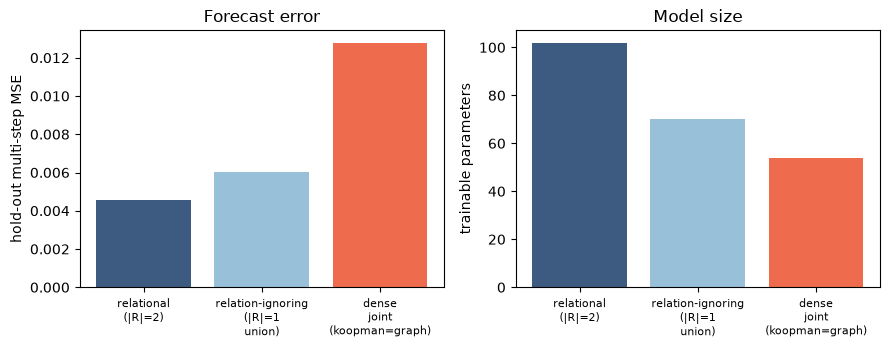

In [8]:
labels = [row["model"].replace(" ", "\n") for row in table]
mses = [row["holdout_mse"] for row in table]
params = [row["params"] for row in table]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6))
axes[0].bar(range(len(mses)), mses, color=["#3d5a80", "#98c1d9", "#ee6c4d"])
axes[0].set_xticks(range(len(labels)), labels, fontsize=8)
axes[0].set_ylabel("hold-out multi-step MSE")
axes[0].set_title("Forecast error")
axes[1].bar(
    range(len(params)), params, color=["#3d5a80", "#98c1d9", "#ee6c4d"]
)
axes[1].set_xticks(range(len(labels)), labels, fontsize=8)
axes[1].set_ylabel("trainable parameters")
axes[1].set_title("Model size")
fig.tight_layout()
plt.show()


## Interpretation / discussion

On this planted multiplex fixture the relational model matches the
data-generating process (two distinct $K_r$) and typically records the lowest
hold-out MSE, at a higher parameter count than the `|R|=1` and homogeneous
arms. That is evidence for the relational operator **when the relations
matter**, not a general ranking. If the union or dense-joint arm wins on
another seed or dataset, the honest conclusion is that relational capacity did
not help forecasting there — document the table rather than retuning until
relational wins. The typed IEEE helper only shows topology construction; it
does not extend this ablation to typed RelGraph training.


## Takeaways

- Use `RelGraphEncoder` / `RelGraphDecoder` with `koopman="hetero_graph"` for
  multiplex relational Koopman models when relation banks are distinct.
- Ablate against a union-adjacency / `|R|=1` control and a homogeneous
  `koopman="graph"` baseline; report parameter counts with hold-out MSE.
- Relational models may lose; keep the negative result visible.
- HGT peers in `koopman_graph.nn` are optional and not factory defaults.
- IEEE typed helpers expose MATPOWER bus roles with **simulated** dynamics
  only; this notebook checks typed construction, not a typed forecast ablation.


## Further reading

- Schlichtkrull et al. (2018), *Modeling Relational Data with Graph
  Convolutional Networks* (R-GCN; per-relation message motivation).
  https://doi.org/10.1007/978-3-319-93417-4_38
- Hu et al. (2020), *Heterogeneous Graph Transformer* (optional HGT peers).
  https://doi.org/10.1145/3366423.3380027
- Package docs: [`docs/source/architecture.rst`](../docs/source/architecture.rst)
  (hetero / RelGraph operator contract),
  [`docs/source/capabilities.rst`](../docs/source/capabilities.rst),
  and [`docs/source/api.rst`](../docs/source/api.rst) for `RelGraphEncoder`,
  `RelGraphDecoder`, and `HeteroGraphKoopmanOperator`.
- Related notebooks: `09_topology_ablation.ipynb`,
  `27_hypergraph_koopman.ipynb`, `38_operator_factorization_ablation.ipynb`.
